In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/jayde/Downloads/customer-retention-analytics/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
print(df.info())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [2]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df["TotalCharges"].isnull().sum())

df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
]

11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [3]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [4]:
df = df.rename(columns={
    "customerID": "customer_id",
    "SeniorCitizen": "senior_citizen",
    "PhoneService": "phone_service",
    "MultipleLines": "multiple_lines",
    "InternetService": "internet_service",
    "OnlineSecurity": "online_security",
    "OnlineBackup": "online_backup",
    "DeviceProtection": "device_protection",
    "TechSupport": "tech_support",
    "StreamingTV": "streaming_tv",
    "StreamingMovies": "streaming_movies",
    "PaperlessBilling": "paperless_billing",
    "PaymentMethod": "payment_method",
    "MonthlyCharges": "monthly_charges",
    "TotalCharges": "total_charges",
    "Churn": "churn"
})

df["churn_flag"] = df["churn"].map({"Yes": 1, "No": 0})

In [5]:
df.to_csv(
    "C:/Users/jayde/Downloads/customer-retention-analytics/data/cleaned/telco_customer_churn_cleaned.csv",
    index=False
)

In [6]:
# 1. Tenure groups
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 36, 48, 60, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-36 Months",
        "37-48 Months",
        "49-60 Months",
        "61-72 Months"
    ]
)

# 2. Monthly charge bands
df["monthly_charge_band"] = pd.cut(
    df["monthly_charges"],
    bins=[0, 30, 60, 90, float("inf")],
    labels=["Low", "Medium", "High", "Very High"]
)

# 3. Revenue at risk
df["monthly_revenue_at_risk"] = np.where(
    df["churn_flag"] == 1,
    df["monthly_charges"],
    0
)

In [7]:
service_columns = [
    "phone_service",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies"
]

df["service_count"] = (
    df[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

In [8]:
df["customer_value_segment"] = pd.qcut(
    df["monthly_charges"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

In [9]:
total_customers = df["customer_id"].nunique()
churned_customers = df["churn_flag"].sum()
churn_rate = df["churn_flag"].mean() * 100
average_tenure = df["tenure"].mean()
average_monthly_charge = df["monthly_charges"].mean()
monthly_revenue = df["monthly_charges"].sum()
monthly_revenue_at_risk = df["monthly_revenue_at_risk"].sum()

print(f"Total Customers: {total_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Average Tenure: {average_tenure:.1f} months")
print(f"Average Monthly Charge: ${average_monthly_charge:,.2f}")
print(f"Monthly Revenue: ${monthly_revenue:,.2f}")
print(f"Monthly Revenue at Risk: ${monthly_revenue_at_risk:,.2f}")

Total Customers: 7,043
Churned Customers: 1,869
Churn Rate: 26.54%
Average Tenure: 32.4 months
Average Monthly Charge: $64.76
Monthly Revenue: $456,116.60
Monthly Revenue at Risk: $139,130.85


In [15]:
contract_churn = (
    df.groupby("contract")["churn_flag"]
    .agg(["count", "sum", "mean"])
)

contract_churn.columns = [
    "total_customers",
    "churned_customers",
    "churn_rate"
]

contract_churn["churn_rate"] *= 100

contract_churn = contract_churn.sort_values(
    "churn_rate",
    ascending=False
)

contract_churn

,total_customers,churned_customers,churn_rate
contract,,,
Month-to-month,3875,1655,42.709677
One year,1473,166,11.269518
Two year,1695,48,2.831858


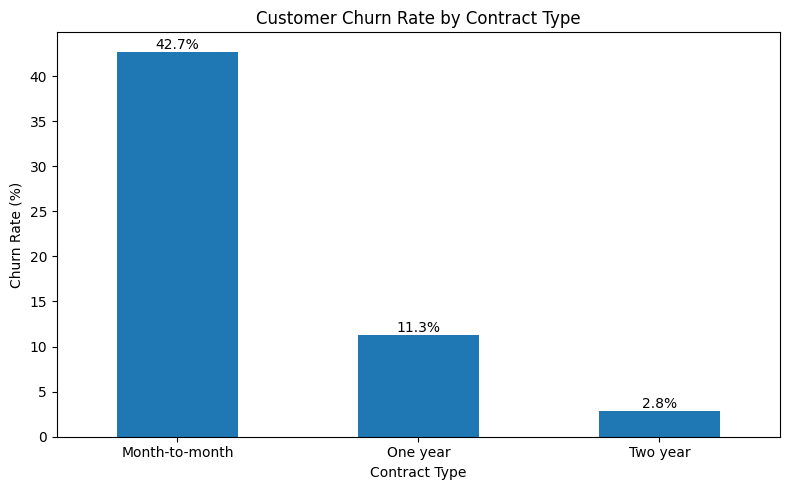

In [16]:
ax = contract_churn["churn_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

### Insight: Contract Type and Churn

- Month-to-month customers had the highest churn rate at 42.71%.
- One-year contract customers had a much lower churn rate of 11.27%.
- Two-year contract customers had the lowest churn rate at 2.83%.
- Longer-term contracts are strongly associated with better customer retention in this dataset.
- A potential business action would be to encourage month-to-month customers to move to longer-term plans through targeted incentives or retention offers.

In [18]:
tenure_churn = (
    df.groupby("tenure_group", observed=False)["churn_flag"]
    .agg(["count", "sum", "mean"])
)

tenure_churn.columns = [
    "total_customers",
    "churned_customers",
    "churn_rate"
]

tenure_churn["churn_rate"] *= 100

tenure_churn

,total_customers,churned_customers,churn_rate
tenure_group,,,
0-12 Months,2186,1037,47.438243
13-24 Months,1024,294,28.710938
25-36 Months,832,180,21.634615
37-48 Months,762,145,19.028871
49-60 Months,832,120,14.423077
61-72 Months,1407,93,6.609808


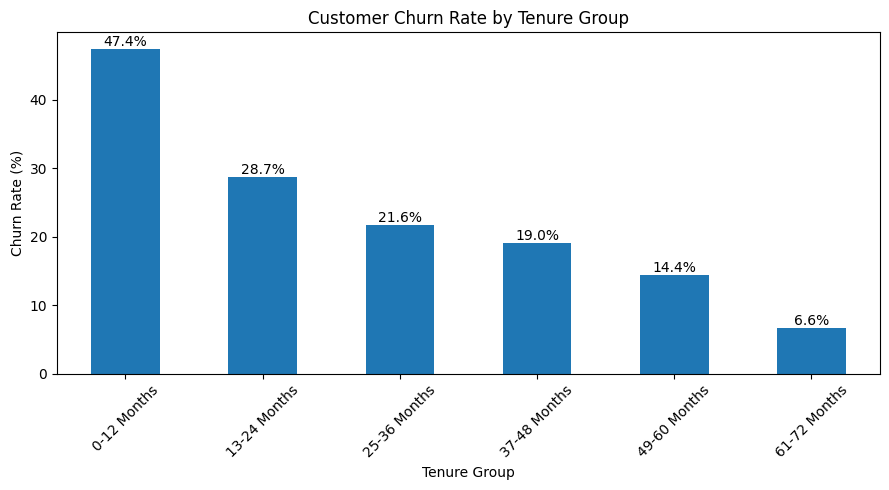

In [19]:
ax = tenure_churn["churn_rate"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Customer Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

### Insight: Tenure and Churn

- Customers in their first 12 months had the highest churn rate at 47.44%.
- Churn decreased consistently as customer tenure increased.
- Customers with 61–72 months of tenure had the lowest churn rate at 6.61%.
- Customer retention appears to improve significantly after the first year.
- A potential business action would be to strengthen onboarding, early customer support, and retention campaigns during the first 12 months.

In [20]:
payment_churn = (
    df.groupby("payment_method")["churn_flag"]
    .agg(["count", "sum", "mean"])
)

payment_churn.columns = [
    "total_customers",
    "churned_customers",
    "churn_rate"
]

payment_churn["churn_rate"] *= 100

payment_churn = payment_churn.sort_values(
    "churn_rate",
    ascending=False
)

payment_churn

,total_customers,churned_customers,churn_rate
payment_method,,,
Electronic check,2365,1071,45.285412
Mailed check,1612,308,19.106700
Bank transfer (automatic),1544,258,16.709845
Credit card (automatic),1522,232,15.243101


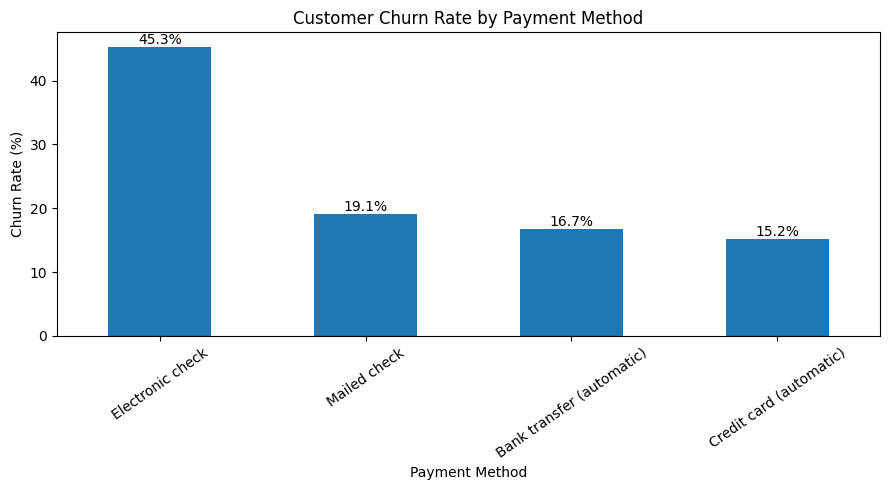

In [21]:
ax = payment_churn["churn_rate"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=35)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

### Insight: Payment Method and Churn

- Customers using electronic checks had the highest churn rate at 45.29%.
- Mailed check customers had a churn rate of 19.11%.
- Customers using automatic bank transfers and credit cards had lower churn rates of 16.71% and 15.24%, respectively.
- Automatic payment methods are associated with stronger customer retention in this dataset.
- A potential business action would be to encourage electronic-check customers to switch to automatic payment options through incentives or simplified enrollment.

In [22]:
tech_support_churn = (
    df.groupby("tech_support")["churn_flag"]
    .agg(["count", "sum", "mean"])
)

tech_support_churn.columns = [
    "total_customers",
    "churned_customers",
    "churn_rate"
]

tech_support_churn["churn_rate"] *= 100

tech_support_churn = tech_support_churn.sort_values(
    "churn_rate",
    ascending=False
)

tech_support_churn

,total_customers,churned_customers,churn_rate
tech_support,,,
No,3473,1446,41.635474
Yes,2044,310,15.166341
No internet service,1526,113,7.404980


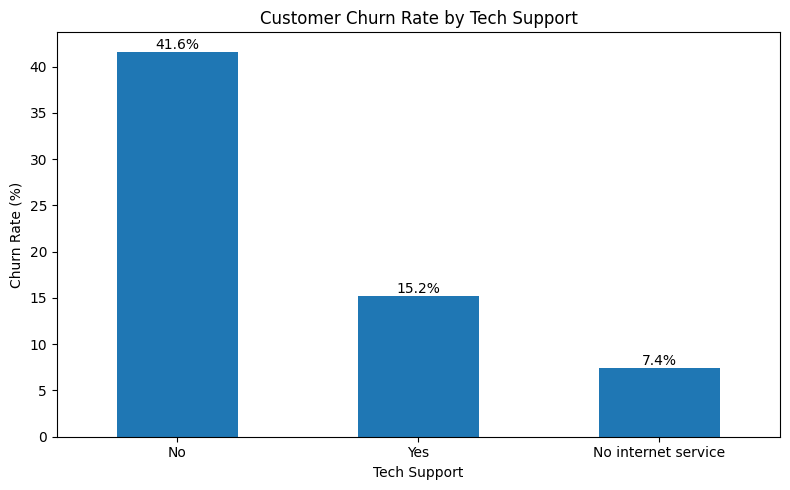

In [23]:
ax = tech_support_churn["churn_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

### Insight: Tech Support and Churn

- Customers without tech support had a churn rate of 41.64%.
- Customers with tech support had a substantially lower churn rate of 15.17%.
- Customers with no internet service had the lowest churn rate at 7.40%, although this group represents a different service profile and should be interpreted separately.
- Tech support usage is strongly associated with improved customer retention among internet-service customers.
- A potential business action would be to promote technical support services to customers who currently do not subscribe, particularly customers already showing other churn-risk characteristics.

In [24]:
monthly_charge_analysis = (
    df.groupby("churn")["monthly_charges"]
    .agg(["count", "mean", "median", "min", "max"])
)

monthly_charge_analysis

,count,mean,median,min,max
churn,,,,,
No,5174,61.265124,64.425,18.25,118.75
Yes,1869,74.441332,79.650,18.85,118.35


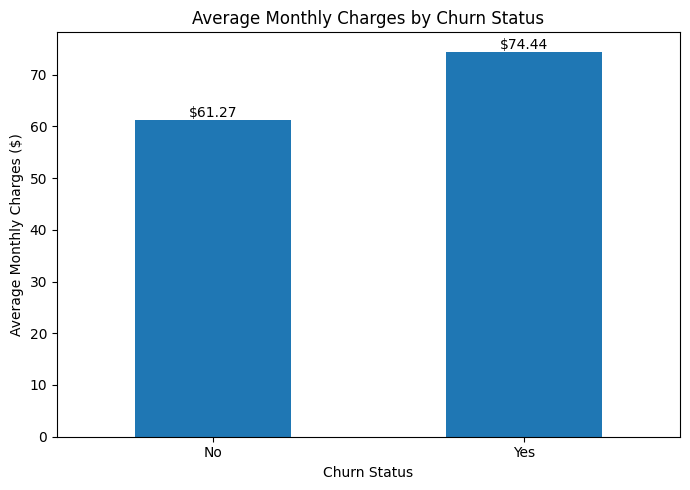

In [25]:
ax = monthly_charge_analysis["mean"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Monthly Charges ($)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="$%.2f")

plt.tight_layout()
plt.show()

In [26]:
charge_band_churn = (
    df.groupby(
        "monthly_charge_band",
        observed=False
    )["churn_flag"]
    .agg(["count", "sum", "mean"])
)

charge_band_churn.columns = [
    "total_customers",
    "churned_customers",
    "churn_rate"
]

charge_band_churn["churn_rate"] *= 100

charge_band_churn

,total_customers,churned_customers,churn_rate
monthly_charge_band,,,
Low,1653,162,9.800363
Medium,1265,328,25.928854
High,2386,809,33.906119
Very High,1739,570,32.777458


### Insight: Monthly Charges and Churn

- Churned customers had a higher average monthly charge ($74.44) than retained customers ($61.27).
- Customers in the Low monthly-charge band had the lowest churn rate at 9.80%.
- Churn increased to 25.93% for Medium-charge customers and approximately 33% for High and Very High-charge customers.
- Higher monthly charges are associated with greater churn in this dataset, although the pattern levels off between the High and Very High groups.
- A potential business action would be to review pricing, perceived value, and retention offers for higher-paying customers, especially those with additional churn-risk characteristics.

In [27]:
service_churn = (
    df.groupby("service_count")["churn_flag"]
    .agg(["count", "sum", "mean"])
)

service_churn.columns = [
    "total_customers",
    "churned_customers",
    "churn_rate"
]

service_churn["churn_rate"] *= 100

service_churn

,total_customers,churned_customers,churn_rate
service_count,,,
0,80,35,43.750000
1,2253,488,21.660009
2,996,433,43.473896
3,1041,361,34.678194
4,1062,289,27.212806
5,827,182,22.007255
6,525,66,12.571429
7,259,15,5.791506


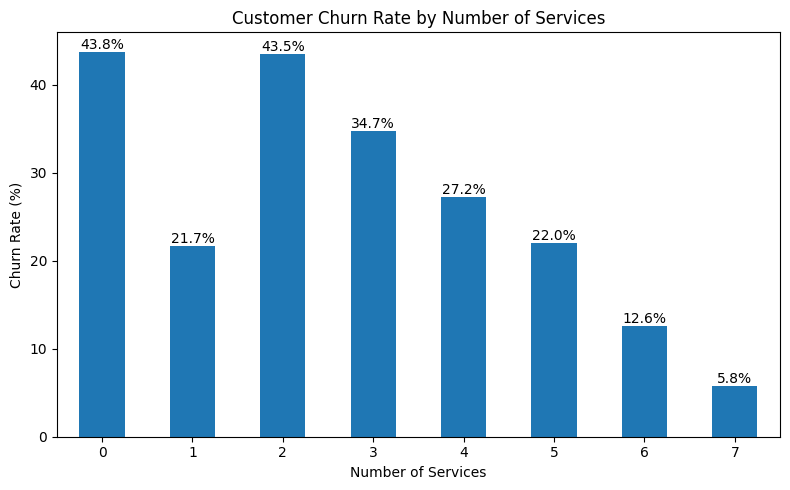

In [28]:
ax = service_churn["churn_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn Rate by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

### Insight: Service Adoption and Churn

- Customers using 6 or 7 services had the lowest churn rates at 12.57% and 5.79%, respectively.
- Churn was substantially higher among customers using only 2 to 4 services.
- Customers using more services generally showed stronger retention, although the relationship was not perfectly linear across all service counts.
- The 0-service group had a high churn rate of 43.75%, but it contained only 80 customers, so this result should be interpreted cautiously.
- A potential business action would be to identify opportunities for relevant service bundling and cross-selling, particularly among customers with low-to-moderate service adoption.

In [29]:
internet_churn = (
    df.groupby("internet_service")["churn_flag"]
    .agg(["count", "sum", "mean"])
)

internet_churn.columns = [
    "total_customers",
    "churned_customers",
    "churn_rate"
]

internet_churn["churn_rate"] *= 100

internet_churn = internet_churn.sort_values(
    "churn_rate",
    ascending=False
)

internet_churn

,total_customers,churned_customers,churn_rate
internet_service,,,
Fiber optic,3096,1297,41.892765
DSL,2421,459,18.959108
No,1526,113,7.404980


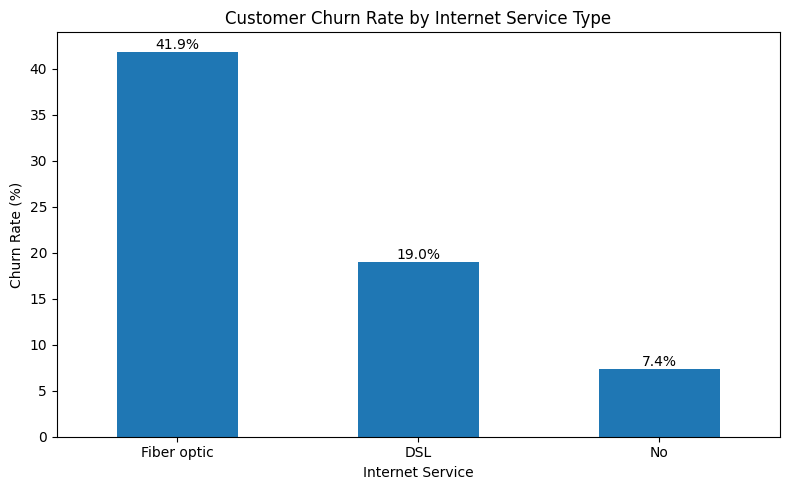

In [30]:
ax = internet_churn["churn_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn Rate by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

### Insight: Internet Service Type and Churn

- Fiber-optic customers had the highest churn rate at 41.89%.
- DSL customers had a substantially lower churn rate of 18.96%.
- Customers without internet service had the lowest churn rate at 7.40%.
- Fiber-optic service is strongly associated with higher churn in this dataset, but the relationship may also reflect differences in pricing, customer profile, or bundled services.
- A potential business action would be to investigate satisfaction, pricing, and support experience among fiber-optic customers and target high-risk customers with retention offers.

## 8. Key Findings

- Overall customer churn rate was 26.54% across 7,043 customers.
- Month-to-month contracts showed the highest churn rate at 42.71%, compared with 11.27% for one-year and 2.83% for two-year contracts.
- Customers in their first 12 months had a 47.44% churn rate, indicating that early-tenure customers are the highest-risk group.
- Electronic-check customers had the highest churn rate at 45.29%, while automatic payment methods were associated with lower churn.
- Customers without tech support had a 41.64% churn rate, compared with 15.17% among customers with tech support.
- Churned customers paid higher monthly charges on average ($74.44) than retained customers ($61.27).
- High and Very High monthly-charge groups showed churn rates of approximately 33%.
- Customers using 6–7 services had substantially lower churn than customers with fewer services.
- Fiber-optic customers had the highest internet-service churn rate at 41.89%.
- The analysis suggests that contract type, tenure, payment method, tech support, pricing, service adoption, and internet-service type are important retention-related factors.

## 9. Business Recommendations

- Focus retention campaigns on month-to-month customers, especially within their first 12 months.
- Encourage high-risk customers to switch to longer-term contracts through targeted incentives.
- Promote automatic payment methods to customers currently using electronic checks.
- Improve onboarding and early-stage customer support to reduce first-year churn.
- Promote tech-support services and relevant service bundles to customers with low service adoption.
- Review pricing and perceived value among higher-paying and fiber-optic customers.
- Prioritize customers who show multiple risk factors, such as short tenure, month-to-month contracts, electronic-check payment, high monthly charges, and no tech support.